# Market Regime GMM vs HMM (4-Regime Alternative Specification)

This notebook builds a basic market regime detection model using macro factor proxy ETFs and a Gaussian Mixture Model.

The goal is not to predict the future. The goal is to learn how unsupervised learning can group market environments based on return behavior.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

## 1. Load Settings

The factor proxies are ETFs that roughly represent broad macro market exposures.

In [2]:
from src.config import (
    COVARIANCE_TYPE,
    END_DATE,
    N_COMPONENTS,
    RANDOM_STATE,
    START_DATE,
    TICKERS,
)

TICKERS

{'Equity': 'ACWI',
 'Rates': 'IEF',
 'Credit': 'LQD',
 'Commodities': 'DBC',
 'EM': 'EEM',
 'FX': 'UUP',
 'ShortVol': 'PUTW',
 'Inflation': 'TIP'}

## 2. Download Adjusted Close Prices

Adjusted prices account for distributions and splits, which makes them better for return calculations.

In [3]:
from src.data import download_adjusted_prices

prices = download_adjusted_prices(TICKERS, START_DATE, END_DATE)
prices.head()

Ticker,Equity,Rates,Credit,Commodities,EM,FX,ShortVol,Inflation
Date,,,,,,,,
2016-02-24,42.963627,87.790482,79.876808,10.669423,24.240391,21.127281,14.393453,83.979248
2016-02-25,43.425861,88.052399,80.323921,10.660968,24.320498,21.110575,14.453562,84.323502
2016-02-26,43.318565,87.623764,80.295967,10.644060,24.080175,21.252590,14.467881,84.106438
2016-02-29,43.087460,87.766632,80.351845,10.779330,24.288452,21.294361,14.433531,84.390831
2016-03-01,44.143997,87.080673,79.913902,10.787784,25.153606,21.302715,14.548028,84.158852


## 3. Compute Returns and Standardize

The model is fitted on daily log returns. Standardization puts all factors on a comparable scale.

In [4]:
from src.features import compute_log_returns, cumulative_returns, standardize_returns

returns = compute_log_returns(prices)
scaled_returns, scaler = standardize_returns(returns)

returns.tail()

Ticker,Equity,Rates,Credit,Commodities,EM,FX,ShortVol,Inflation
Date,,,,,,,,
2026-05-20,0.012652,0.006743,0.007718,-0.023365,0.018502,-0.002161,0.003009,0.002359
2026-05-21,0.003797,0.000640,0.002036,-0.005846,0.008670,0.000000,0.001801,0.000000
2026-05-22,0.001925,0.000852,0.001847,-0.005225,-0.002274,0.001441,0.001049,0.000091
2026-05-26,0.011790,0.004252,0.003776,-0.016840,0.037538,-0.000720,0.002346,0.003978
2026-05-27,-0.001649,0.000424,0.001011,-0.016790,-0.001902,-0.000721,0.000000,0.000181


## GMM Model Selection

AIC and BIC compare GMM fits with different numbers of regimes. Lower values are preferred.

In [5]:
import pandas as pd
from src.gmm_model import gmm_model_selection
from src.plots import plot_model_selection

gmm_selection = gmm_model_selection(
    scaled_returns,
    component_range=range(2, 7),
    covariance_type=COVARIANCE_TYPE,
    random_state=RANDOM_STATE,
)

gmm_selection.round(2)

,AIC,BIC
n_components,,
2,38499.15,39020.22
3,37276.74,38061.28
4,37116.35,38164.36
5,37100.05,38411.52
6,37073.85,38648.78


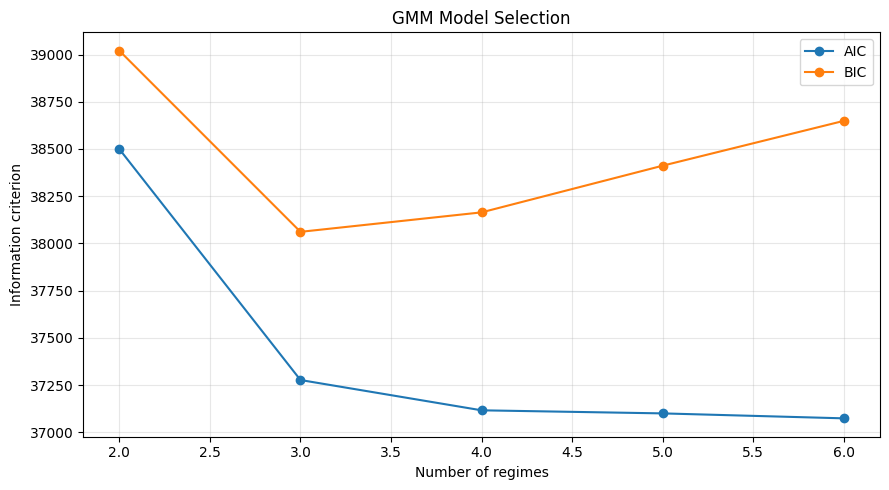

In [6]:
plot_model_selection(gmm_selection);

## 4. Fit the GMM

A Gaussian Mixture Model finds clusters of days with similar return patterns. Here we ask it to find four regimes.

In [7]:
from src.gmm_model import fit_gmm_regimes, validate_regime_outputs

gmm, labels, probabilities = fit_gmm_regimes(
    scaled_returns,
    n_components=N_COMPONENTS,
    covariance_type=COVARIANCE_TYPE,
    random_state=RANDOM_STATE,
)   

validate_regime_outputs(returns, labels, probabilities, N_COMPONENTS)
labels.value_counts().sort_index()

Regime
0     511
1    1363
2      36
3     668
Name: count, dtype: int64

## 5. Cumulative Return Chart

This shows how each factor proxy performed over the sample.

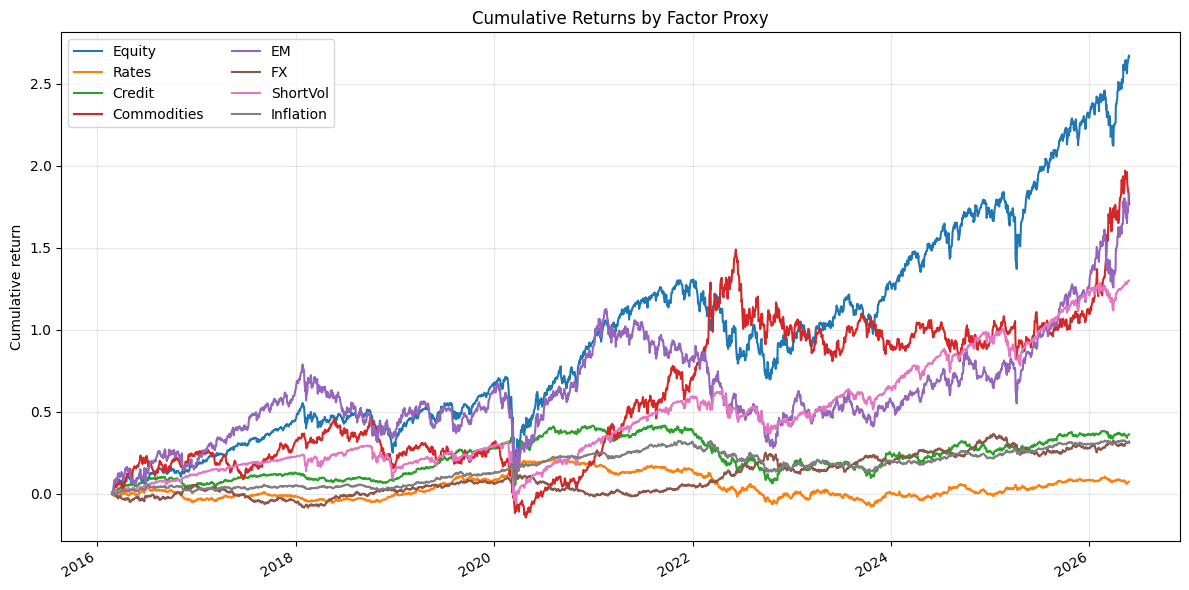

In [8]:
from src.plots import plot_cumulative_returns

plot_cumulative_returns(returns);

## 6. ACWI Colored by Regime

The model labels each day as one of four regimes. The numbers are model clusters, not economic names.

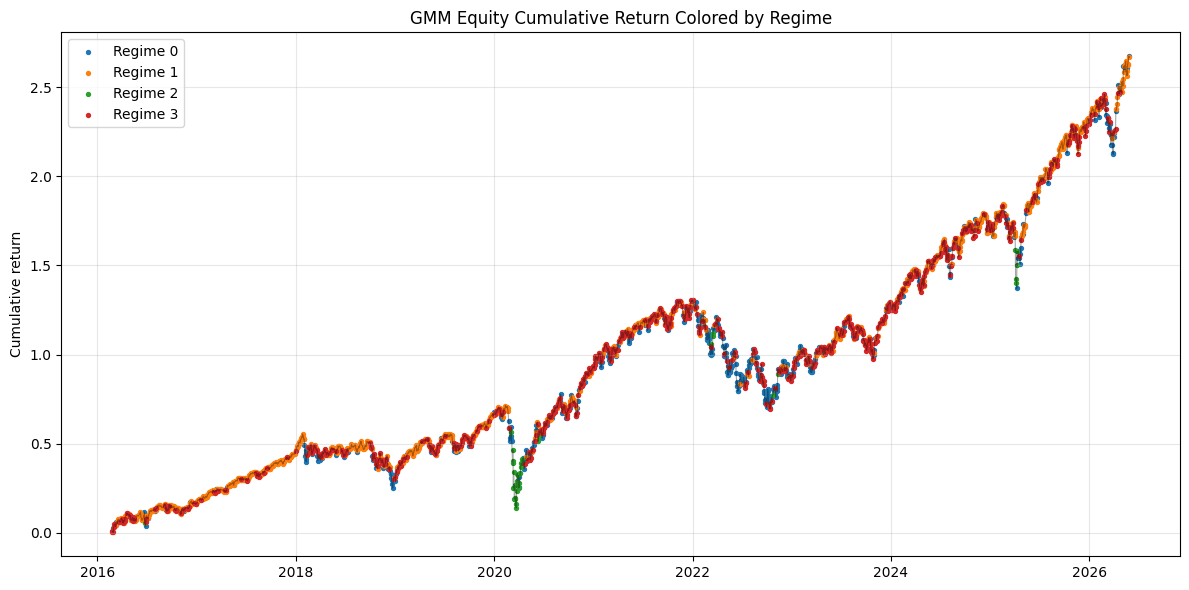

In [9]:
from src.plots import plot_regime_colored_series

cum_returns = cumulative_returns(returns)
plot_regime_colored_series(cum_returns, labels, column="Equity");

## 7. Regime Probability Chart

GMMs produce probabilities, not only hard labels. A high probability means the model is more confident about that regime on that day.

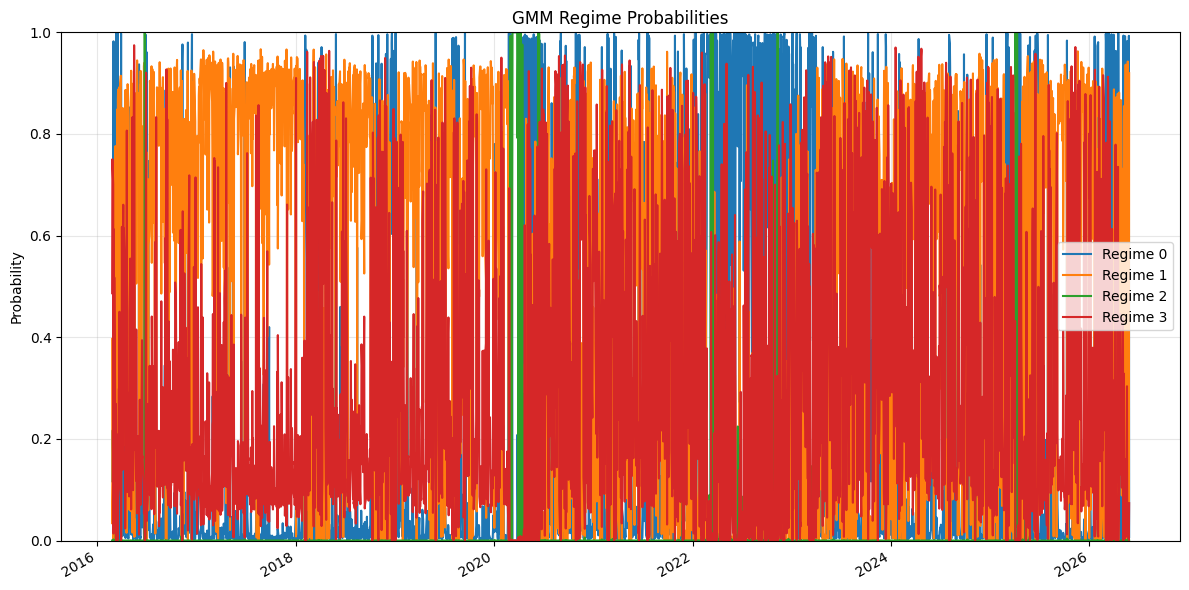

In [10]:
from src.plots import plot_regime_probabilities

plot_regime_probabilities(probabilities);

## 8. Regime Statistics

Use these tables to infer what each regime may mean economically.

In [11]:
from src.analysis import compact_interpretation_table, regime_correlations, regime_summary

summary = regime_summary(returns, labels)
interpretation = compact_interpretation_table(summary)
interpretation.round(4)

,Frequency,AvgCorrelation,Equity_Return,EM_Return,Rates_Return,Credit_Return,Commodities_Return,FX_Return,Inflation_Return,Equity_Volatility,Equity_Sharpe
Regime,,,,,,,,,,,
0,0.1982,0.1517,-0.5657,-0.6832,0.1721,0.1184,-0.5357,0.0164,0.0923,0.2441,-2.3175
1,0.5287,0.1172,0.2863,0.2560,0.0582,0.1211,0.1837,0.0216,0.0728,0.0740,3.8684
2,0.0140,0.2357,-0.3062,-1.1945,0.1950,0.1613,-2.0851,-0.0238,-0.0107,0.8224,-0.3723
3,0.2591,0.1780,0.3554,0.4553,-0.2339,-0.2295,0.5315,0.0472,-0.1140,0.1365,2.6041


## 9. Correlations by Regime

Correlation often rises during stressful markets. These heatmaps show how factor relationships differ by regime.

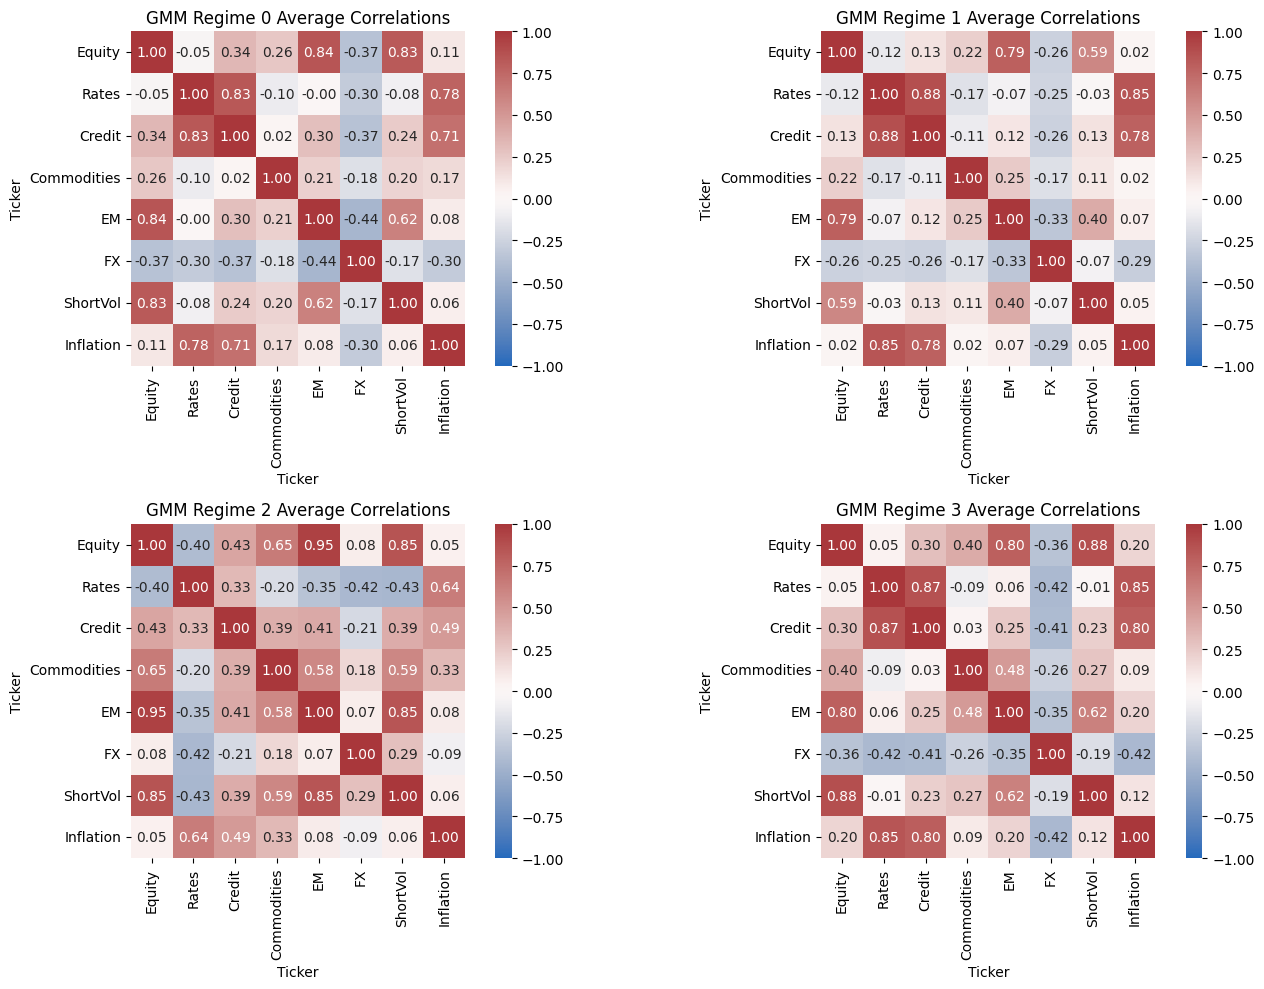

In [12]:
from src.plots import plot_factor_return_table, plot_factor_volatility_table, plot_regime_correlation_heatmaps

correlations = regime_correlations(returns, labels)
plot_regime_correlation_heatmaps(correlations);

## 10. Factor Volatility Table

This exhibit-style table compares annualized factor volatility across the four model regimes.

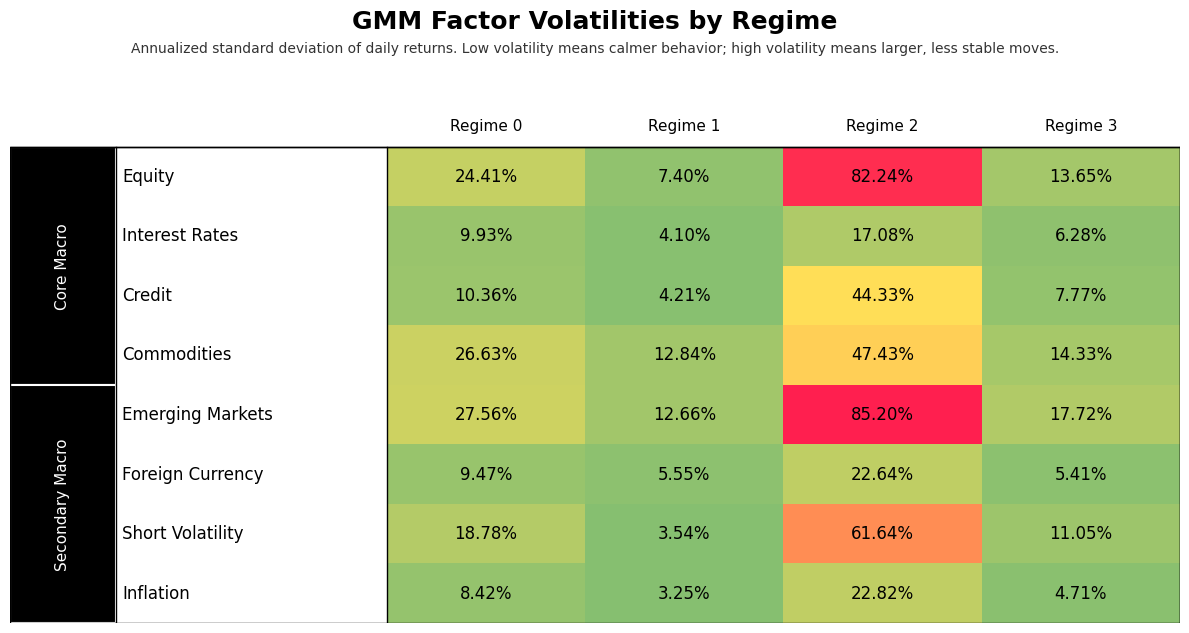

In [13]:
plot_factor_volatility_table(summary);

## 11. Factor Return Table

This table uses the same layout to compare annualized factor returns across regimes.

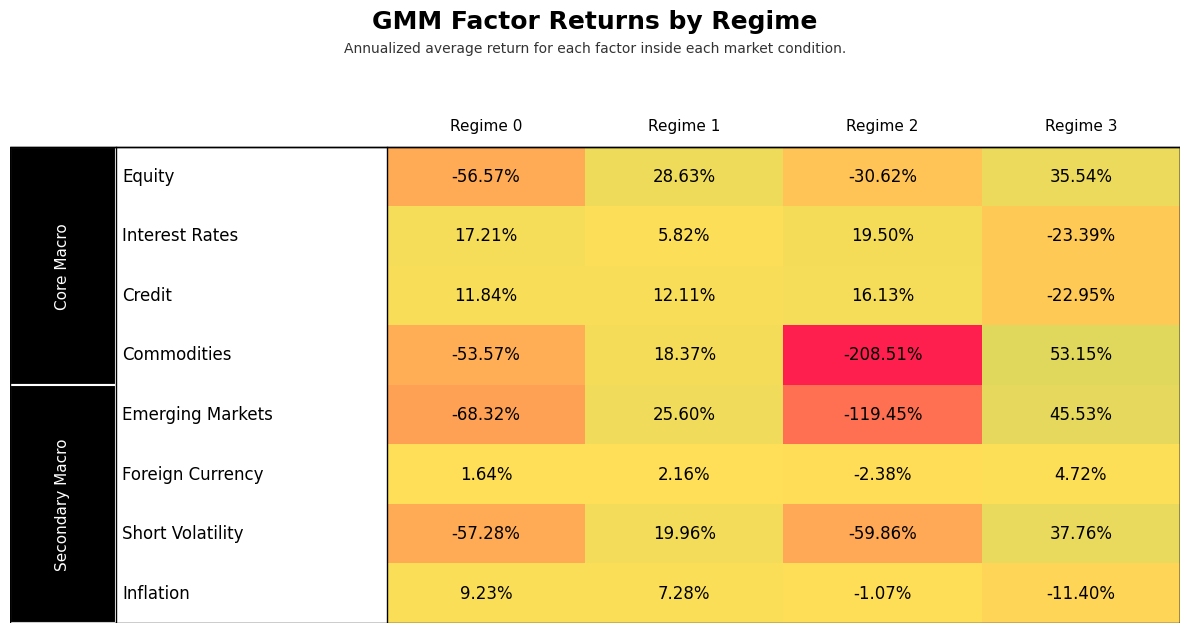

In [14]:
plot_factor_return_table(summary);

## Economic Interpretation Guide

Do not hardcode regime names. Instead, inspect each regime's return, volatility, frequency, and correlation profile.

- Weak equity and EM returns, high volatility, and high average correlations may suggest a crisis-like regime.
- Broad positive returns with lower volatility may suggest a calm regime.
- Strong commodities and inflation-linked bonds with weak nominal bonds may suggest inflationary pressure.
- Strong risk assets with elevated volatility may suggest speculative or high-volatility behavior.

The regime number itself has no permanent meaning. It is only the cluster ID assigned by the model.

## GMM Transition Diagnostics

These diagnostics show how often the static GMM labels switch from one regime to another.

In [15]:
from src.analysis import (
    regime_duration_stats,
    regime_performance_summary,
    transition_matrix,
)
from src.plots import plot_transition_heatmap

gmm_transition_counts = transition_matrix(labels, n_regimes=N_COMPONENTS, normalize=False)
gmm_transition_probabilities = transition_matrix(labels, n_regimes=N_COMPONENTS, normalize=True)
gmm_durations = regime_duration_stats(labels)
gmm_performance = regime_performance_summary(returns, labels)

gmm_transition_probabilities.round(3)

To,0,1,2,3
From,,,,
0,0.423,0.235,0.025,0.317
1,0.101,0.705,0.001,0.193
2,0.389,0.000,0.583,0.028
3,0.216,0.424,0.000,0.361


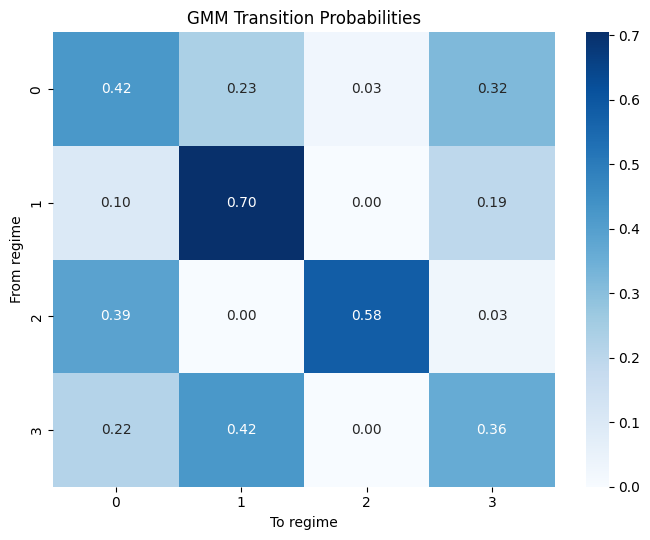

In [16]:
plot_transition_heatmap(
    gmm_transition_probabilities,
    title="GMM Transition Probabilities",
    fmt=".2f",
);

In [17]:
gmm_durations.round(2)

,Count,Mean,Median,Min,Max
Regime,,,,,
0,295,1.73,1.0,1,12
1,403,3.38,2.0,1,51
2,15,2.40,1.0,1,16
3,427,1.56,1.0,1,8


In [18]:
gmm_performance[gmm_performance["Factor"].eq("Equity")].round(4)

,Regime,Factor,AnnualReturn,AnnualVolatility,Sharpe,Observations
0,0,Equity,-0.5657,0.2441,-2.3175,511
8,1,Equity,0.2863,0.0740,3.8684,1363
16,2,Equity,-0.3062,0.8224,-0.3723,36
24,3,Equity,0.3554,0.1365,2.6041,668


In [19]:
gmm_means = pd.DataFrame(gmm.means_, columns=scaled_returns.columns)
gmm_means.index.name = "Regime"
gmm_means.round(3)

Ticker,Equity,Rates,Credit,Commodities,EM,FX,ShortVol,Inflation
Regime,,,,,,,,
0,-0.191,0.130,0.053,-0.160,-0.179,-0.020,-0.236,0.065
1,0.057,0.041,0.059,0.028,0.047,-0.006,0.054,0.043
2,-0.156,0.198,0.148,-0.770,-0.361,-0.024,-0.299,-0.046
3,0.066,-0.173,-0.140,0.121,0.083,0.025,0.112,-0.113


## Gaussian Hidden Markov Model

The HMM uses the same standardized return features, but estimates regimes with time-dependent transition probabilities.

In [20]:
from src.hmm_model import fit_hmm_regimes, validate_hmm_outputs

hmm, hmm_labels, hmm_probabilities = fit_hmm_regimes(
    scaled_returns,
    n_components=N_COMPONENTS,
    covariance_type=COVARIANCE_TYPE,
    random_state=RANDOM_STATE,
)
validate_hmm_outputs(returns, hmm_labels, hmm_probabilities, N_COMPONENTS)

hmm_labels.value_counts().sort_index()

HiddenState
0     501
1    1368
2      66
3     643
Name: count, dtype: int64

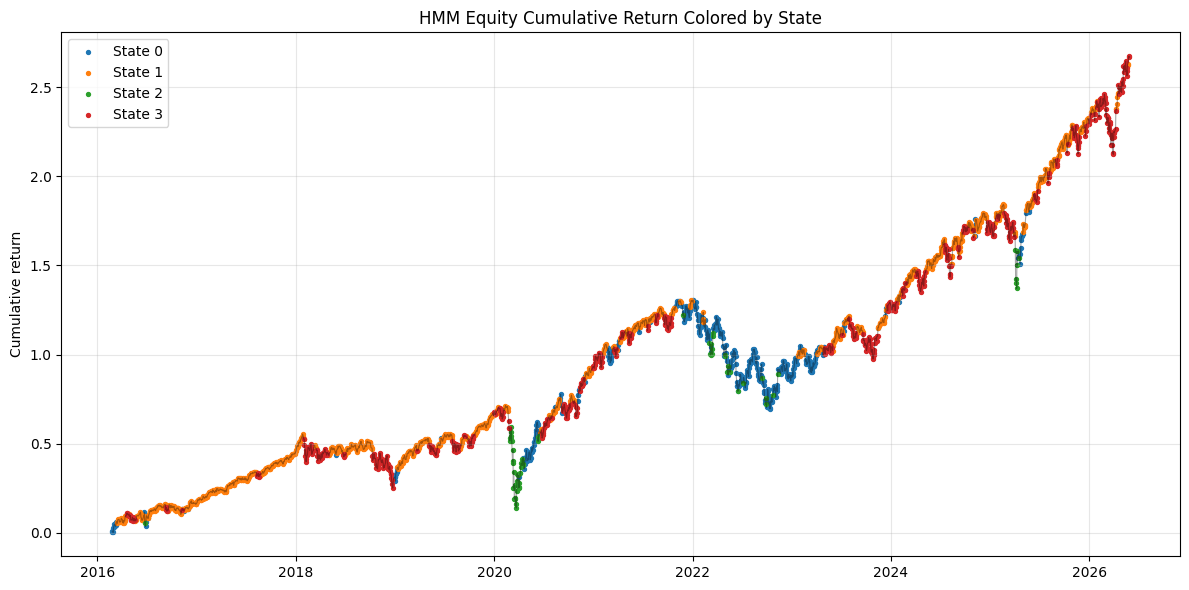

In [21]:
plot_regime_colored_series(cum_returns, hmm_labels, column="Equity");

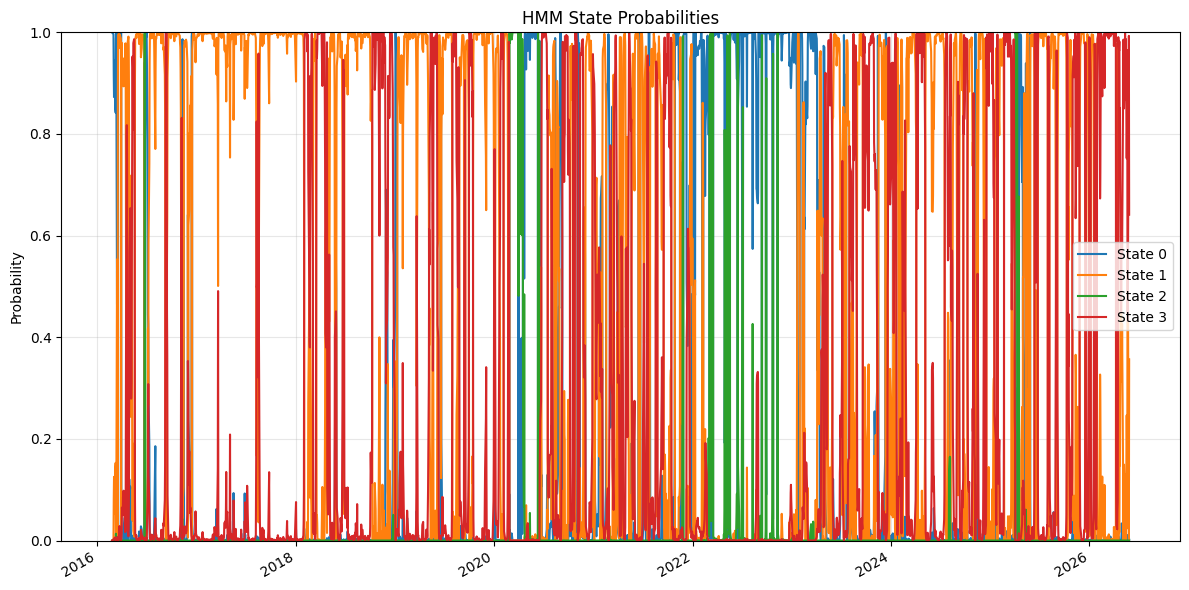

In [22]:
plot_regime_probabilities(hmm_probabilities);

In [23]:
hmm_means = pd.DataFrame(hmm.means_, columns=scaled_returns.columns)
hmm_means.index.name = "State"
hmm_means.round(3)

Ticker,Equity,Rates,Credit,Commodities,EM,FX,ShortVol,Inflation
State,,,,,,,,
0,0.056,-0.070,-0.038,0.076,0.030,-0.006,0.067,-0.038
1,0.066,-0.005,0.022,0.036,0.056,-0.017,0.061,0.007
2,-0.593,0.378,0.042,-0.741,-0.619,-0.083,-0.748,0.049
3,-0.121,0.026,-0.021,-0.058,-0.077,0.049,-0.102,0.009


## HMM Transition Diagnostics

The transition matrix is estimated directly by the HMM and summarizes state persistence.

In [24]:
hmm_transition_probabilities = pd.DataFrame(
    hmm.transmat_,
    index=range(N_COMPONENTS),
    columns=range(N_COMPONENTS),
)
hmm_transition_probabilities.index.name = "From"
hmm_transition_probabilities.columns.name = "To"

hmm_transition_counts = transition_matrix(hmm_labels, n_regimes=N_COMPONENTS, normalize=False)
hmm_durations = regime_duration_stats(hmm_labels)
hmm_performance = regime_performance_summary(returns, hmm_labels)

hmm_transition_probabilities.round(3)

To,0,1,2,3
From,,,,
0,0.869,0.076,0.038,0.017
1,0.025,0.912,0.001,0.062
2,0.319,0.000,0.681,0.000
3,0.015,0.125,0.002,0.858


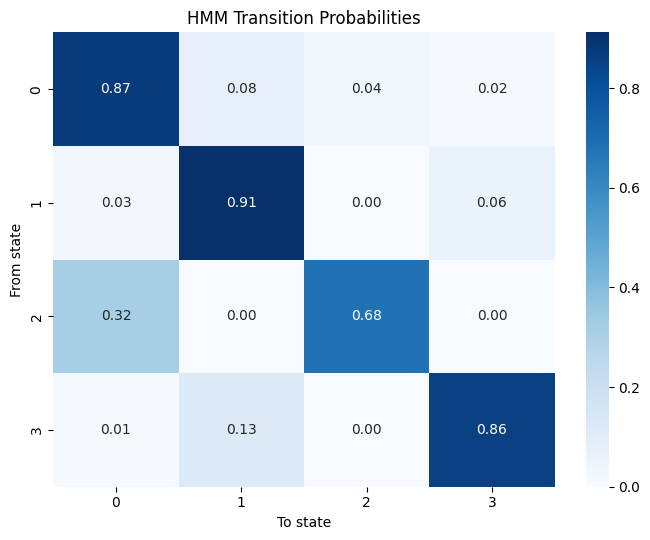

In [25]:
plot_transition_heatmap(
    hmm_transition_probabilities,
    title="HMM Transition Probabilities",
    fmt=".2f",
);

In [26]:
hmm_durations.round(2)

,Count,Mean,Median,Min,Max
Regime,,,,,
0,53,9.45,5.0,1,48
1,85,16.09,9.0,1,162
2,19,3.47,1.0,1,23
3,57,11.28,7.0,1,52


In [27]:
hmm_performance[hmm_performance["Factor"].eq("Equity")].round(4)

,Regime,Factor,AnnualReturn,AnnualVolatility,Sharpe,Observations
0,0,Equity,0.2732,0.1926,1.4184,501
8,1,Equity,0.3241,0.0807,4.0169,1368
16,2,Equity,-1.4566,0.6448,-2.2590,66
24,3,Equity,-0.2437,0.1741,-1.3993,643


## GMM vs HMM Comparison

This compares the static GMM labels against the HMM hidden states on the same dates.

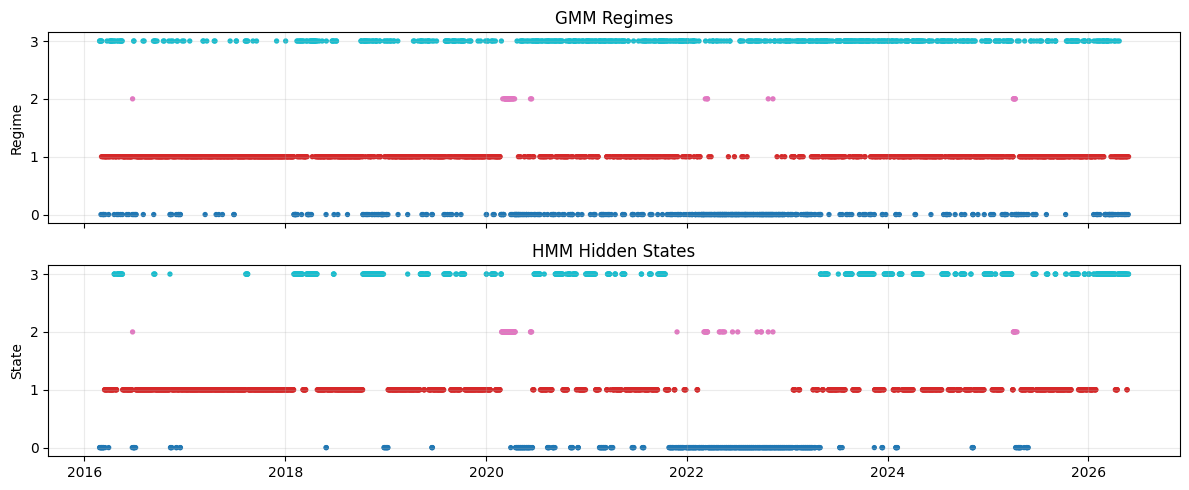

In [28]:
from src.analysis import label_confusion_matrix, persistence_table
from src.plots import plot_regime_timeline_comparison

plot_regime_timeline_comparison(labels, hmm_labels);

In [29]:
label_confusion_matrix(labels, hmm_labels).astype(int)

HMM,0,1,2,3
GMM,,,,
0,290,30,30,161
1,52,1141,0,170
2,0,0,36,0
3,159,197,0,312


In [30]:
persistence_comparison = pd.DataFrame({
    "GMM_Label_Persistence": persistence_table(gmm_transition_probabilities)["Persistence"],
    "HMM_State_Persistence": persistence_table(hmm_transition_probabilities)["Persistence"],
})

persistence_comparison.round(3)

,GMM_Label_Persistence,HMM_State_Persistence
Regime,,
0,0.423,0.869
1,0.705,0.912
2,0.583,0.681
3,0.361,0.858


In [31]:
duration_comparison = pd.concat(
    {
        "GMM": gmm_durations["Mean"],
        "HMM": hmm_durations["Mean"],
    },
    axis=1,
)

duration_comparison.round(2)

,GMM,HMM
Regime,,
0,1.73,9.45
1,3.38,16.09
2,2.40,3.47
3,1.56,11.28


## Conclusions from n_components = 4

AIC keeps improving up to 6 components, while BIC is lowest at 3 components. Since BIC penalizes complexity more, 3 may be the more efficient choice. We still use 4 components because it gives clearer economic separation between normal, strong, weak, and extreme market regimes.

### GMM Regimes

| Regime | Possible Label | Finding |
|---|---|---|
| Regime 0 | Calm Growth | Main calm-growth regime; most frequent, positive Equity/EM returns, low Equity volatility, strongest Sharpe. |
| Regime 1 | Risk-On Expansion | Higher-risk risk-on regime; strong Equity, EM, Rates, and Credit returns, but higher volatility. |
| Regime 2 | Crisis / Market Stress | Stress/crisis regime; very negative Equity and EM returns, weak Credit, higher correlations, poor Sharpe. |
| Regime 3 | Defensive Shock | Rare extreme/dislocation regime; very high Equity volatility, weak Commodities and EM, but positive Rates and Credit. |

### HMM States

| State | Possible Label | Finding |
|---|---|---|
| State 1 | Calm Growth | Main calm positive regime; most observations, strong Equity returns, low volatility, highest Sharpe. |
| State 0 | Mixed Recovery / Expansion | Mixed positive regime; positive Equity and Commodities, but weaker Rates and Credit. |
| State 2 | Extreme Stress | Extreme stress state; very negative Equity, EM, Commodities, and ShortVol with very high volatility. |
| State 3 | Mild Stress | Weaker risk-off regime; negative Equity and EM returns, but less severe than State 2. |

### GMM vs HMM

The main difference between GMM and HMM is persistence. The GMM labels switch often because GMM clusters each day based mainly on return similarity, without explicitly modeling time dependence. The HMM produces smoother and longer-lasting regimes because it estimates transition probabilities between hidden states. This is clear from the duration and persistence tables: HMM states have much higher self-transition probabilities and much longer average durations than GMM regimes.

Overall, the GMM is useful for identifying return-pattern clusters, while the HMM is better for describing market regimes as time-dependent states. In this analysis, both models identify a calm positive regime and a severe stress regime, but the HMM gives a more realistic regime timeline because market environments usually persist rather than changing randomly day to day.